In [1]:
import pandas as pd
from pathlib import Path
import glob
import seaborn as sns
import matplotlib.pyplot as plt
import math



In [4]:
respath = Path("../../results/synthetic/s123")
#respath = Path("/Users/jangorecki/PythonWork/bcause/papers/gradient_journal/results/synthetic/s123")    # TODO : set the local path here
filenames = glob.glob(f"{respath}/*.csv")
print(len(filenames))

filenames

213


['../../results/synthetic/s123/random_mc2_n6_mid3_d1000_05_mr098_r10_23_uai_EMCC_x200_iter25_tolNone_roTrue_s1.csv',
 '../../results/synthetic/s123/random_mc2_n7_mid3_d1000_05_mr098_r10_139_uai_EMCC_x200_iter25_tolNone_roTrue_s1.csv',
 '../../results/synthetic/s123/random_mc2_n5_mid3_d1000_05_mr098_r10_189_uai_EMCC_x200_iter25_tolNone_roTrue_s1.csv',
 '../../results/synthetic/s123/random_mc2_n9_mid3_d1000_05_mr098_r10_42_uai_EMCC_x200_iter25_tolNone_roTrue_s1.csv',
 '../../results/synthetic/s123/random_mc2_n5_mid3_d1000_05_mr098_r10_31_uai_EMCC_x200_iter25_tolNone_roTrue_s1.csv',
 '../../results/synthetic/s123/random_mc2_n6_mid3_d1000_05_mr098_r10_81_uai_EMCC_x200_iter25_tolNone_roTrue_s1.csv',
 '../../results/synthetic/s123/random_mc2_n9_mid3_d1000_05_mr098_r10_91_uai_EMCC_x2_iter25_tolNone_roTrue_s1.csv',
 '../../results/synthetic/s123/random_mc2_n7_mid3_d1000_05_mr098_r10_131_uai_EMCC_x200_iter25_tolNone_roTrue_s1.csv',
 '../../results/synthetic/s123/random_mc2_n5_mid3_d1000_05_mr09

In [5]:
#data = pd.concat([pd.read_csv(respath.joinpath(f), index_col=0) for f in filenames], axis=0, ignore_index=True)
data = pd.concat([pd.read_csv(f, index_col=0) for f in filenames], axis=0, ignore_index=True)


In [6]:
data["time"]= data.tlearn + data.tinfer

In [7]:
data

,modelname,method,cause,effect,tol,num_runs_param,max_iter_param,seed,tlearn,tinfer,remove_outliers,datasize,pns_low_exact,pns_upp_exact,pns_low,pns_upp,rrmse,rmse,nruns,time
0,random_mc2_n6_mid3_d1000_05_mr098_r10_23,EMCC,V0,V5,NaN,200,25.0,1,2703.306437,47.353983,True,2000,0.0,0.206565,0.028494,0.028494,inf,0.127517,1,2750.660419
1,random_mc2_n6_mid3_d1000_05_mr098_r10_23,EMCC,V0,V5,NaN,200,25.0,1,5265.976191,91.620922,True,2000,0.0,0.206565,0.028494,0.065550,2.745285,0.101728,2,5357.597113
2,random_mc2_n6_mid3_d1000_05_mr098_r10_23,EMCC,V0,V5,NaN,200,25.0,1,7842.676878,138.510704,True,2000,0.0,0.206565,0.019261,0.065550,2.174164,0.100639,3,7981.187582
3,random_mc2_n6_mid3_d1000_05_mr098_r10_23,EMCC,V0,V5,NaN,200,25.0,1,10418.355465,184.118748,True,2000,0.0,0.206565,0.019261,0.079850,1.495821,0.090630,4,10602.474213
4,random_mc2_n6_mid3_d1000_05_mr098_r10_23,EMCC,V0,V5,NaN,200,25.0,1,13001.939535,232.844830,True,2000,0.0,0.206565,0.000805,0.079850,1.133571,0.089603,5,13234.784365
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32149,random_mc2_n5_mid3_d1000_05_mr098_r10_151,EMCC,V1,V2,NaN,200,25.0,1,367154.249907,8676.751375,True,1000,0.0,0.312918,0.007518,0.277685,0.094291,0.025474,196,375831.001282
32150,random_mc2_n5_mid3_d1000_05_mr098_r10_151,EMCC,V1,V2,NaN,200,25.0,1,369524.067879,8606.155396,True,1000,0.0,0.312918,0.007518,0.277685,0.094291,0.025474,197,378130.223274
32151,random_mc2_n5_mid3_d1000_05_mr098_r10_151,EMCC,V1,V2,NaN,200,25.0,1,371897.031069,8637.519836,True,1000,0.0,0.312918,0.007518,0.277685,0.094291,0.025474,198,380534.550905
32152,random_mc2_n5_mid3_d1000_05_mr098_r10_151,EMCC,V1,V2,NaN,200,25.0,1,374272.081852,8820.269108,True,1000,0.0,0.312918,0.007518,0.277685,0.094291,0.025474,199,383092.350960


In [35]:
data["iter"] = data["max_iter_param"]

# Select the relevant data
df = data[["nruns", "time",  'rmse', 'method', "remove_outliers", "iter", "tol"]]


df = df.drop(df[df.iter.isin([25, 200])].index)
df = df.drop(df[df.tol.isin([0.001])].index)
df["method2"] = df.apply(lambda t : t["method"]+" "+[f"{c}={t[c]}" for c in ["iter", "tol"] if not math.isnan(t[c])][0] if t["method"]!="GSCC" else "GSCC", axis=1)

In [36]:
df["method2"].unique()

array(['GDCC tol=1e-09', 'EMCC iter=100.0', 'GDCC tol=1e-05',
       'EMCC iter=50.0', 'GDCC tol=1e-07', 'GSCC', 'EMCC iter=150.0'],
      dtype=object)

<AxesSubplot:xlabel='nruns', ylabel='time'>

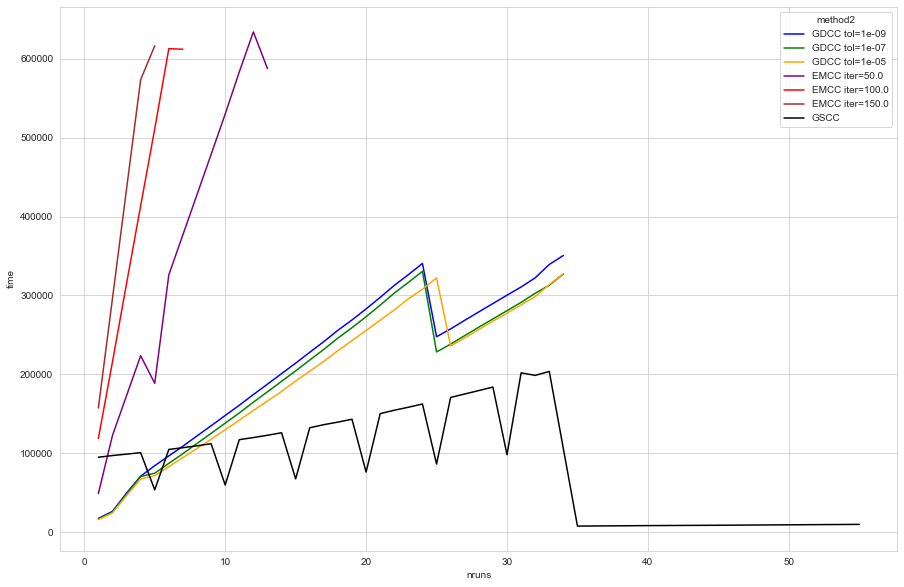

In [39]:
# Define custom colors for each method
custom_palette = {
    "GDCC tol=1e-09": "blue",
    "GDCC tol=1e-07": "green",
    "GDCC tol=1e-05": "orange",
    "EMCC iter=50.0": "purple",
    "EMCC iter=100.0": "red",
    "EMCC iter=150.0": "brown",
    "GSCC": "black"
}

# Define the order based on increasing values
hue_order = ["GDCC tol=1e-09", "GDCC tol=1e-07", "GDCC tol=1e-05", 
             "EMCC iter=50.0", "EMCC iter=100.0", "EMCC iter=150.0", "GSCC"]

# Time with outliers removal
fig, ax = plt.subplots(figsize=(15, 10))
# Plot with custom colors and sorted legend
sns.lineplot(
    data=df.loc[df.remove_outliers==True], 
    x="nruns", y="time", 
    hue="method2", 
    errorbar=None, 
    palette=custom_palette, 
    hue_order=hue_order
)

<AxesSubplot:xlabel='nruns', ylabel='rmse'>

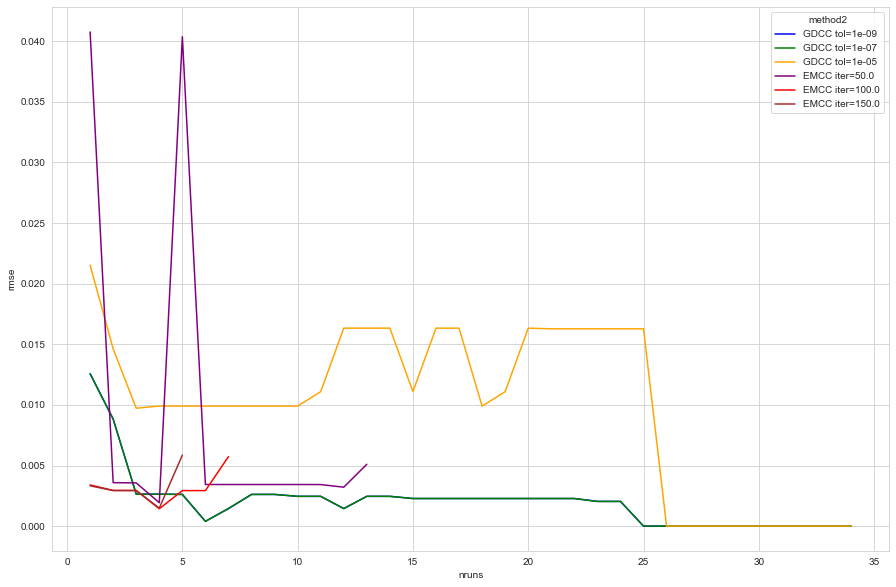

In [38]:
# Error with outliers removal
fig, ax = plt.subplots(figsize=(15, 10))
# Plot with custom colors and sorted legend
sns.lineplot(
    data=df.loc[df.remove_outliers==True], 
    x="nruns", y="rmse", 
    hue="method2", 
    errorbar=None, 
    palette=custom_palette, 
    hue_order=hue_order
)